# Technical Analysis of Historical Stock Data

This notebook computes technical indicators such as SMA, EMA, RSI, and MACD to analyze stock market trends and momentum.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_ta as ta

In [11]:
import yfinance as yf

df = yf.download('AAPL', start='2020-01-01', end='2021-01-01')
df.columns = df.columns.get_level_values(0)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [12]:
df.index = pd.to_datetime(df.index, utc=True)

In [13]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02 00:00:00+00:00,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03 00:00:00+00:00,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06 00:00:00+00:00,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07 00:00:00+00:00,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08 00:00:00+00:00,73.085106,73.386423,71.631552,71.631552,132079200


In [14]:
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Missing values were removed to ensure accurate calculation of technical indicators.


In [15]:
df['SMA_20'] = ta.sma(df['Close'], length=20)

df['SMA_50'] = ta.sma(df['Close'], length=50)

In [16]:
df['EMA_20'] = ta.ema(df['Close'], length=20)

Moving averages smooth price fluctuations and help identify long-term trends. # type: ignore

In [17]:
df['RSI'] = ta.rsi(df['Close'], length=14)

In [18]:
macd = ta.macd(df['Close'])

df['MACD'] = macd['MACD_12_26_9']
df['MACD_signal'] = macd['MACDs_12_26_9']
df['MACD_hist'] = macd['MACDh_12_26_9']

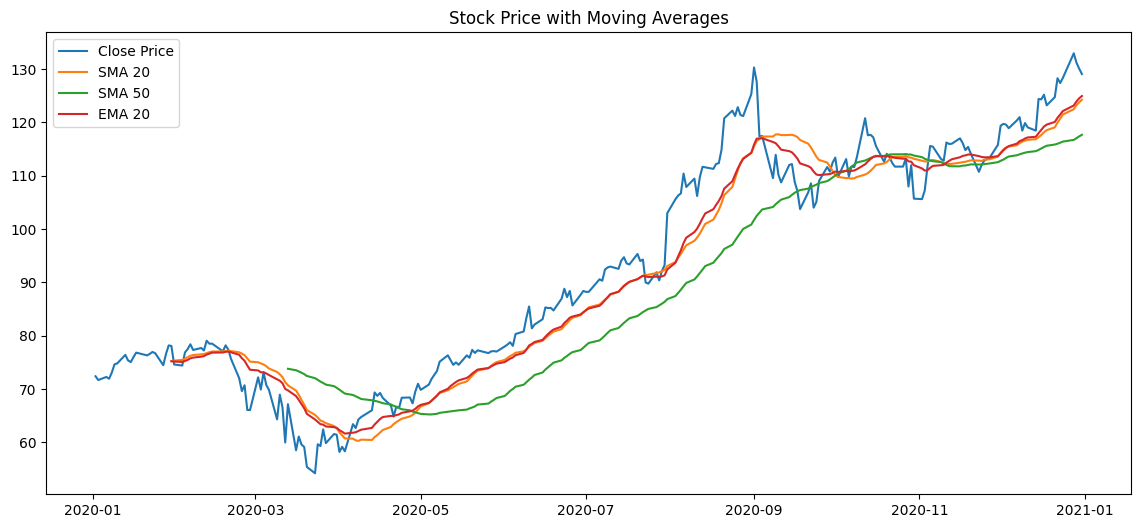

In [19]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['SMA_20'], label='SMA 20')
plt.plot(df.index, df['SMA_50'], label='SMA 50')
plt.plot(df.index, df['EMA_20'], label='EMA 20')

plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()

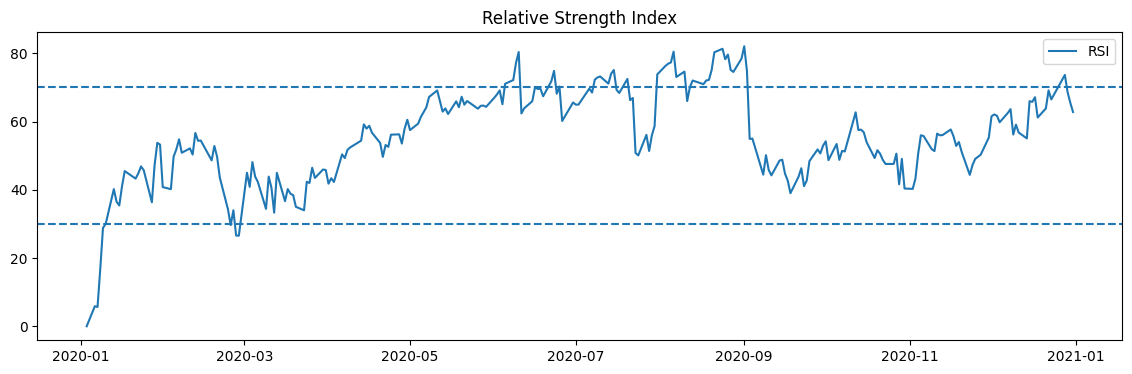

In [20]:
plt.figure(figsize=(14,4))

plt.plot(df.index, df['RSI'], label='RSI')

plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title("Relative Strength Index")
plt.legend()
plt.show()

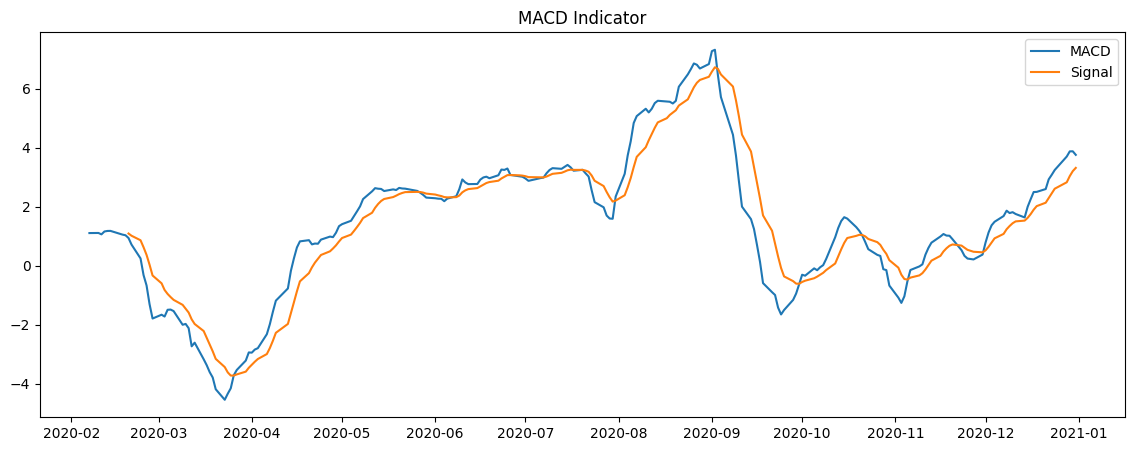

In [21]:
plt.figure(figsize=(14,5))

plt.plot(df.index, df['MACD'], label='MACD')
plt.plot(df.index, df['MACD_signal'], label='Signal')

plt.title("MACD Indicator")
plt.legend()
plt.show()